In [1]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

from joblib import load

from src.featuring import build_dataset, nutrisc_algo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# from src.tools import len_list

import gc
gc.collect()

# Model pretrain
pipeline_charge = load('./model/lgb_pipeline_2025_09_22.joblib')
X, X_out, y, y_out, X_all, y_all = build_dataset()

# # Calcul des résidus
y_pred = pipeline_charge.predict(X_out)
residus = y_out - y_pred

# Ajout d'information
pth = './data/processed/nutrient_cleaned.parquet'
df = pl.read_parquet(pth)
df = df.with_row_index()
idx_out = y_out.index
y_pred = pl.DataFrame(
    {
        'index': idx_out, 
        'nutriscore_score': y_out,
        'y_pred': y_pred,
        'residus': residus,
    }
    )
df_out = df.join(y_pred, on="index", how="inner")
df_out = df_out.with_columns(
    pl.col("y_pred").round(0).cast(pl.Int64)
)

# Verif
# (df_out.select([
#     (pl.col("nutriscore_score") == pl.col("nutriscore_score_right")).all()
#     ]))
# df_b.filter(pl.col("ypred_grade").is_null())
# df.select(pl.col('is_fats_nuts_seeds').value_counts())

{'cereals': np.int64(0), 'dairy_products': np.int64(1), 'fruits_vege_legumes': np.int64(2), 'meat_fish_eggs': np.int64(3), 'processed_food': np.int64(4), 'salty_snacks_sauces': np.int64(5), 'sweet_desserts': np.int64(6), None: np.int64(7)}
{'bakery_bread': np.int64(0), 'cereal_and_pasta': np.int64(1), 'dairy_and_egg': np.int64(2), 'fish_eafood': np.int64(3), 'fruit': np.int64(4), 'meals_and_condiments': np.int64(5), 'meat': np.int64(6), 'plant_based_products': np.int64(7), 'snacks_and_sweets': np.int64(8), 'supplements_and_sweeteners': np.int64(9), 'vegetable': np.int64(10), None: np.int64(11)}


In [6]:
# # Nb de données sans catégories
# df_out.filter(
#     (pl.col('tag_0').is_null()) & # 141_249
#     (pl.col('tag2_0').is_null()) & # 82_518
#     (pl.col('residus') > 5)
#     )

#### Les résidus

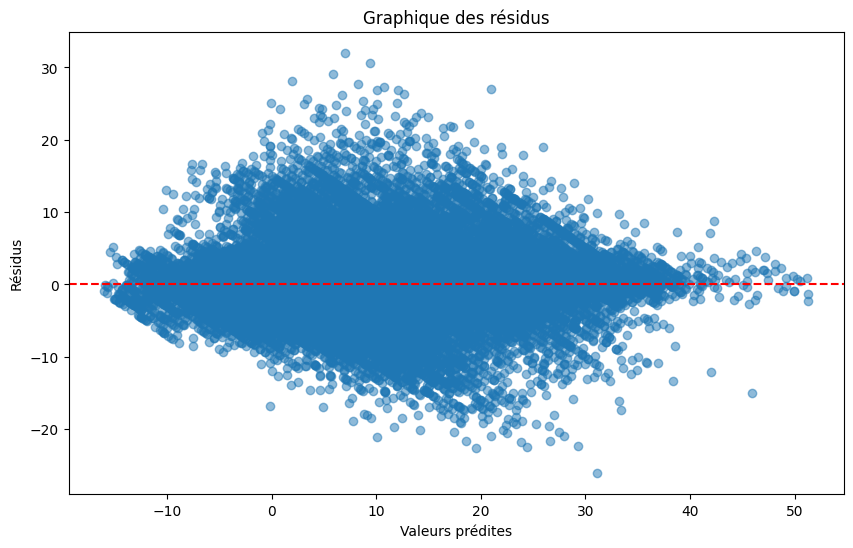

In [ ]:
# trace les résidus
plt.figure(figsize=(10, 6))
plt.scatter(pipeline_charge.predict(X_out), residus, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel('Résidus')
plt.title('Graphique des résidus')
plt.show()

In [ ]:
# Calculer le grade
c = 'y_pred'
df_out = nutrisc_algo(df_out, c)

c = 'nutriscore_score'
df_out = nutrisc_algo(df_out, c)

n = df_out.shape[0]
print('n out = ', n)

# df_out.filter(
#     (pl.col("residus").abs() > 5) &
#     (pl.col('food_groups_tags') == [])
# )

n out =  180814


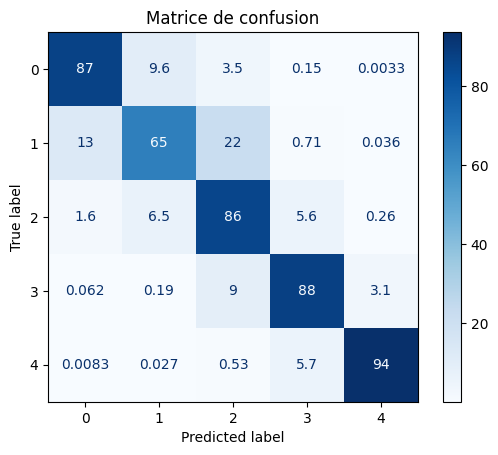

In [ ]:
ypred_grade = df_out.select(pl.col('y_pred_grade'))
y_grade = df_out.select(pl.col('nutriscore_score_grade'))

cm = confusion_matrix(y_grade, ypred_grade)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

In [ ]:
# Interprétation des résultats :

# Diagonale : Taux de bonne classification (VP).
# Hors diagonale : Erreurs de classification (FP/FN).
# Lignes : Rappel (sensibilité) de chaque classe. Vraies classes.
# Colonnes : Précision de chaque classe. Classes prédites.

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_grade, ypred_grade))

              precision    recall  f1-score   support

           A       0.91      0.87      0.89     30336
           B       0.66      0.65      0.66     16525
           C       0.78      0.86      0.82     37595
           D       0.89      0.88      0.89     48446
           E       0.97      0.94      0.95     47912

    accuracy                           0.87    180814
   macro avg       0.84      0.84      0.84    180814
weighted avg       0.87      0.87      0.87    180814

